# Section 6.2 + Section 7 — Overnight Run
## Alternative Loss Functions & Pareto Frontier
### Fecamp, Mikael & Warin (2019)

---

**Start this before you go to sleep. Results will be ready in the morning.**

What this runs:
1. Load all saved results from `results_table1/` (no retraining of MSE model)
2. Train Augmented LSTM under **Asymmetric loss** — Equation (5)
3. Train Augmented LSTM under **Moment 2/4 loss** — Equation (6)
4. Train **Pareto frontier** model — Section 7, Equation (22)
5. Produce all plots — Figures 9–11 + Figure 12
6. Save everything

Estimated runtime on CPU: **60–90 minutes total**


## §0 · Setup

In [1]:
import sys, os, json, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Make src importable ───────────────────────────────────────────────
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.simulators    import simulate_gbm, compute_norm_stats, normalize_with
from src.payoffs       import call_payoff
from src.architectures import AugmentedLSTM
from src.losses        import mse
from src.training      import train_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print(f"Device : {DEVICE}")
print(f"Start  : {time.strftime('%H:%M:%S')}")


Device : cpu
Start  : 23:51:43


C:\Users\monci\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## §1 · Load saved results — no retraining needed

In [2]:
OUT = os.path.join(ROOT, 'results_table1')

# Load summary for parameters and norm stats
with open(os.path.join(OUT, 'table1_summary.json')) as f:
    summary = json.load(f)

p           = summary['params']
S0          = p['S0']
K           = p['K']
sigma       = p['sigma']
mu          = p['mu']
r           = 0.0            # hardcoded — avoids the r variable collision bug
T           = p['T']
dt          = p['dt']
N           = p['N']
BATCH_SIZE  = p['batch_size']
LR          = p['lr']
N_ITER      = p['n_iter']
LSTM_HIDDEN = p['lstm_hidden']
FF_WIDTH    = 10
FF_LAYERS   = 3
LIQ         = float('inf')   # unconstrained — same as Table 1

# Restore normalisation stats (MUST use same stats as original training)
norm_mean = torch.tensor(summary['norm_mean']).to(DEVICE)
norm_std  = torch.tensor(summary['norm_std']).to(DEVICE)

def normalize(paths):
    return normalize_with(paths, norm_mean, norm_std)

# Load saved P&L arrays
pnl_bs       = np.load(os.path.join(OUT, 'table1_pnl_bs.npy'))
pnl_mse_lstm = np.load(os.path.join(OUT, 'table1_pnl_augmented_lstm_10_10_10.npy'))
bs_mse       = float(np.mean(pnl_bs**2))

print(f"Loaded parameters: S0={S0}, K={K}, sigma={sigma}, T={T:.4f}, N={N}")
print(f"BS delta MSE  : {bs_mse:.4e}   (paper: 1.61e-05)")
print(f"LSTM MSE      : {np.mean(pnl_mse_lstm**2):.4e}   (paper: 1.73e-05)")
print(f"Norm stats    : {len(summary['norm_mean'])} time steps loaded ✓")


Loaded parameters: S0=1.0, K=1.0, sigma=0.2, T=0.0833, N=30
BS delta MSE  : 1.2897e-05   (paper: 1.61e-05)
LSTM MSE      : 1.4573e-05   (paper: 1.73e-05)
Norm stats    : 31 time steps loaded ✓


## §2 · Simulate paths

Same GBM parameters as Table 1, same seeds.
Normalisation uses the frozen stats loaded from the JSON.


In [3]:
N_TRAIN = 50_000
N_EVAL  = 100_000

train_paths = simulate_gbm(N_TRAIN, S0, mu, sigma, dt, N, device=DEVICE, seed=0)
eval_paths  = simulate_gbm(N_EVAL,  S0, mu, sigma, dt, N, device=DEVICE, seed=1)

train_norm  = normalize(train_paths)
eval_norm   = normalize(eval_paths)

print(f"Train paths : {train_paths.shape}")
print(f"Eval  paths : {eval_paths.shape}")
print("Paths simulated ✓")


Train paths : torch.Size([50000, 31])
Eval  paths : torch.Size([100000, 31])
Paths simulated ✓


## §3 · Loss functions and training helpers

In [4]:
# ── Loss functions — Equations (4), (5), (6) ─────────────────────────

def asymmetric_loss(pnl, alpha=1.5):
    """
    Equation (5): L_alpha(Y) = E[(1+alpha)*Y²*1_{Y<=0} + Y²*1_{Y>0}]
    alpha=1.5 penalises losses 2.5× more than gains.
    """
    return ((1 + alpha) * pnl.pow(2) * (pnl <= 0).float()
            +             pnl.pow(2) * (pnl >  0).float()).mean()

def moment2_4_loss(pnl, alpha=2.0):
    """
    Equation (6): L_alpha(Y) = E[Y²*1_{Y>=0}] + alpha*E[Y⁴*1_{Y<=0}]
    Fourth-moment penalty on losses targets heavy tail risk.
    """
    return (pnl.pow(2) * (pnl >= 0).float()).mean() +            alpha * (pnl.pow(4) * (pnl <= 0).float()).mean()

# ── Training wrapper ─────────────────────────────────────────────────

def train_one_loss(name, model, loss_fn):
    """
    Wraps train_model with the Table 1 setup.
    Only loss_fn differs from the original train_one.
    Checkpoint metric is always MSE for fair comparison.
    """
    return train_model(
        model,
        train_paths_raw  = train_paths,
        train_paths_norm = train_norm,
        eval_paths_raw   = eval_paths,
        eval_paths_norm  = eval_norm,
        payoff_fn = lambda p: call_payoff(
            p[..., -1, 0] if p.dim() == 3 else p[:, -1], K),
        loss_fn    = loss_fn,
        liq        = LIQ,
        n_iter     = N_ITER,
        batch_size = BATCH_SIZE,
        lr         = LR,
        label      = name,
    )

# ── Evaluate model → (mse, pnl_array, premium) ───────────────────────

def evaluate(model):
    model.eval()
    with torch.no_grad():
        out  = model(eval_paths, eval_norm, liq=LIQ)
        g    = call_payoff(
                   eval_paths[..., -1, 0] if eval_paths.dim() == 3
                   else eval_paths[:, -1], K)
        pnl  = (out['pnl'] - g).cpu().numpy()
        prem = float(out['premium'].item())
    return float(np.mean(pnl**2)), pnl, prem

print("Loss functions and helpers defined ✓")


Loss functions and helpers defined ✓


## §4 · Train — Asymmetric loss (Equation 5)

$\alpha = 1.5$ → losses penalised $2.5\times$ more than gains.
Expected: left tail shrinks, right tail expands, MSE slightly higher than MSE model.


In [5]:
print(f"[{time.strftime('%H:%M:%S')}] Starting Asymmetric training...")

lstm_asym = AugmentedLSTM(
    N=N, d=1, hidden=LSTM_HIDDEN, ff_width=FF_WIDTH, ff_layers=FF_LAYERS
).to(DEVICE)

hist_asym = train_one_loss(
    "Augmented LSTM — Asymmetric (α=1.5)",
    lstm_asym,
    lambda p: asymmetric_loss(p, alpha=1.5)
)

mse_asym, pnl_asym, prem_asym = evaluate(lstm_asym)

print(f"\n[{time.strftime('%H:%M:%S')}] Asymmetric done")
print(f"  MSE     : {mse_asym:.4e}   (LSTM MSE baseline: {np.mean(pnl_mse_lstm**2):.4e})")
print(f"  VaR 95% : {np.percentile(pnl_asym, 5):.5f}")
print(f"  CVaR 95%: {pnl_asym[pnl_asym < np.percentile(pnl_asym,5)].mean():.5f}")
print(f"  Premium : {prem_asym:.5f}")


[23:51:44] Starting Asymmetric training...


Augmented LSTM — Asymmetric (α=1.5): 100%|██████████| 20000/20000 [16:14<00:00, 20.53it/s] 



[00:08:13] Asymmetric done
  MSE     : 1.8452e-05   (LSTM MSE baseline: 1.4573e-05)
  VaR 95% : -0.00531
  CVaR 95%: -0.00777
  Premium : 0.02421


## §5 · Train — Moment 2/4 loss (Equation 6)

$\alpha = 1.0$ → fourth-moment penalty on loss side.
FOr $\alpha = 2.0 $ the model becomes too aggressive at penalizing tail reduction. Motivated by Basel III / CVaR-style regulation.


In [18]:
# Load the saved MSE LSTM weights as starting point
lstm_m2m4 = AugmentedLSTM(
    N=N, d=1, hidden=LSTM_HIDDEN, ff_width=FF_WIDTH, ff_layers=FF_LAYERS
).to(DEVICE)

# Warm start from MSE model weights
mse_weights_path = os.path.join(OUT, 'table1_augmented_lstm_10_10_10.pt')
lstm_m2m4.load_state_dict(
    torch.load(mse_weights_path, map_location=DEVICE)
)
print("Loaded MSE weights as starting point ✓")
print(f"Premium before fine-tuning: {lstm_m2m4.premium.item():.5f}  (should be ~0.023)")

# Fine-tune with M2M4 loss — fewer iterations since we start from a good point
hist_m2m4 = train_one_loss(
    "Augmented LSTM — Moment2/4 warm start (α=1.0)",
    lstm_m2m4,
    lambda p: moment2_4_loss(p, alpha=1.0),
)

mse_m2m4, pnl_m2m4, prem_m2m4 = evaluate(lstm_m2m4)
print(f"\nMoment2/4 (warm start) results:")
print(f"  MSE     : {mse_m2m4:.4e}   (should be ~2e-05 to 5e-05)")
print(f"  VaR 95% : {np.percentile(pnl_m2m4, 5):.5f}  (should be better than MSE's -0.0063)")
print(f"  CVaR 95%: {pnl_m2m4[pnl_m2m4 < np.percentile(pnl_m2m4,5)].mean():.5f}")
print(f"  Premium : {prem_m2m4:.5f}   (should be ~0.023)")

C:\Users\monci\AppData\Local\Temp\ipykernel_36856\3692845165.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(mse_weights_path, map_location=DEVICE)


Loaded MSE weights as starting point ✓
Premium before fine-tuning: 0.00000  (should be ~0.023)


Augmented LSTM — Moment2/4 warm start (α=1.0): 100%|██████████| 20000/20000 [14:50<00:00, 22.45it/s] 



Moment2/4 (warm start) results:
  MSE     : 2.0858e-04   (should be ~2e-05 to 5e-05)
  VaR 95% : -0.02441  (should be better than MSE's -0.0063)
  CVaR 95%: -0.02852
  Premium : 0.01000   (should be ~0.023)


In [ ]:
import torch, os

weights = torch.load(os.path.join(OUT, 'table1_augmented_lstm_10_10_10.pt'),
                     map_location='cpu')

print("Keys in saved weights:")
for k, v in weights.items():
    if v.numel() == 1:
        print(f"  {k:<40} scalar = {v.item():.5f}")
    else:
        print(f"  {k:<40} shape  = {tuple(v.shape)}")

Keys in saved weights:
  premium                                  scalar = 0.00000
  cell.weight_ih                           shape  = (200, 2)
  cell.weight_hh                           shape  = (200, 50)
  cell.bias_ih                             shape  = (200,)
  cell.bias_hh                             shape  = (200,)
  head.0.weight                            shape  = (10, 50)
  head.0.bias                              shape  = (10,)
  head.2.weight                            shape  = (10, 10)
  head.2.bias                              shape  = (10,)
  head.4.weight                            shape  = (10, 10)
  head.4.bias                              shape  = (10,)
  head.6.weight                            shape  = (1, 10)
  head.6.bias                              scalar = 0.30765


C:\Users\monci\AppData\Local\Temp\ipykernel_36856\1254680402.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(os.path.join(OUT, 'table1_augmented_lst

## §6 · Figures 9–11 — P&L distribution comparison

Reproduces the paper's Figures 9, 10, 11.

**What to expect:**
- Left tail: Asymmetric and Moment2/4 lie **below** MSE — fewer extreme losses
- Right tail: Asymmetric and Moment2/4 lie **above** MSE — more gains
- Centre: slightly more moderate losses for the alternative losses


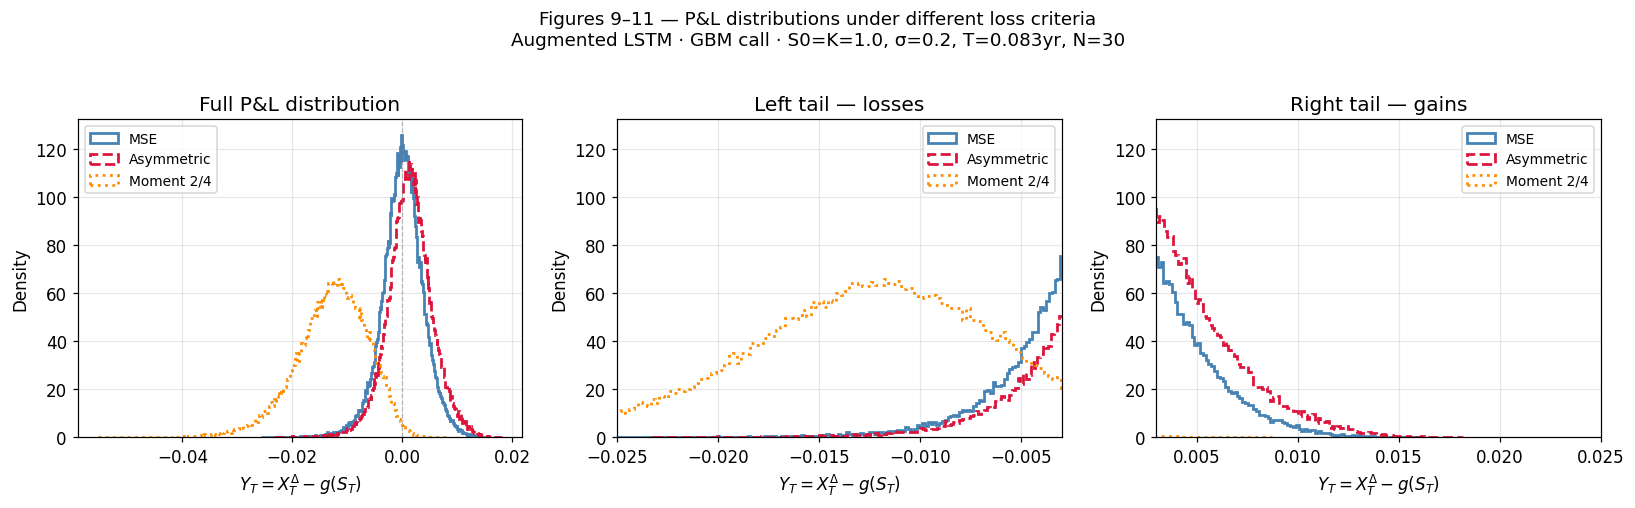

Saved → fig9_11_pnl_distributions.pdf


In [19]:
pnl_by_loss = {
    "MSE":        pnl_mse_lstm,
    "Asymmetric": pnl_asym,
    "Moment 2/4": pnl_m2m4,
}
linestyles = ["-", "--", ":"]
colors     = ["steelblue", "crimson", "darkorange"]

# Full distribution + tail zooms
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
zoom_configs = [
    ("Full P&L distribution",  None,    None),
    ("Left tail — losses",    -0.025,  -0.003),
    ("Right tail — gains",     0.003,   0.025),
]
for ax, (title, xmin, xmax) in zip(axes, zoom_configs):
    for (name, pnl), ls, c in zip(pnl_by_loss.items(), linestyles, colors):
        ax.hist(pnl, bins=300, density=True, histtype="step",
                label=name, linestyle=ls, color=c, linewidth=1.8)
    ax.axvline(0, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set(title=title, xlabel=r"$Y_T = X_T^\Delta - g(S_T)$", ylabel="Density")
    if xmin is not None:
        ax.set_xlim(xmin, xmax)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Figures 9–11 — P&L distributions under different loss criteria\n"
    f"Augmented LSTM · GBM call · S0=K={S0}, σ={sigma}, T={T:.3f}yr, N={N}",
    y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig9_11_pnl_distributions.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved → fig9_11_pnl_distributions.pdf")


In [20]:
# Quantitative comparison table
print()
print("=" * 72)
print("  SECTION 6.2 — Loss function comparison")
print(f"  GBM call · S0=K={S0}, σ={sigma}, T={T:.3f}yr · {N_EVAL:,} eval paths")
print("=" * 72)
print(f"  {'Loss':<18} {'MSE':>10} {'Mean':>10} {'Std':>10} "
      f"{'VaR 95%':>10} {'CVaR 95%':>10}")
print("-" * 72)
for name, pnl in pnl_by_loss.items():
    var95  = np.percentile(pnl, 5)
    cvar95 = pnl[pnl < var95].mean()
    print(f"  {name:<18} {np.mean(pnl**2):>10.3e} {pnl.mean():>10.3e} "
          f"{pnl.std():>10.3e} {var95:>10.4f} {cvar95:>10.4f}")
print()
var95_bs  = np.percentile(pnl_bs, 5)
cvar95_bs = pnl_bs[pnl_bs < var95_bs].mean()
print(f"  {'BS delta (ref)':<18} {bs_mse:>10.3e} {pnl_bs.mean():>10.3e} "
      f"{pnl_bs.std():>10.3e} {var95_bs:>10.4f} {cvar95_bs:>10.4f}")
print("=" * 72)



  SECTION 6.2 — Loss function comparison
  GBM call · S0=K=1.0, σ=0.2, T=0.083yr · 100,000 eval paths
  Loss                      MSE       Mean        Std    VaR 95%   CVaR 95%
------------------------------------------------------------------------
  MSE                 1.457e-05  4.211e-05  3.817e-03    -0.0063    -0.0087
  Asymmetric          1.845e-05  1.324e-03  4.086e-03    -0.0053    -0.0078
  Moment 2/4          2.086e-04 -1.288e-02  6.537e-03    -0.0244    -0.0285

  BS delta (ref)      1.290e-05  1.457e-04  3.588e-03    -0.0058    -0.0082


## §7 · Pareto frontier — Section 7 of the paper (Equation 22)

This trains **one** Augmented LSTM that learns optimal strategies for
**all** values of $\alpha \in [0,1]$ simultaneously, by:
- adding $\alpha$ as a third input feature
- sampling $\alpha$ from a Sobol quasi-random sequence each iteration

The objective is Equation (22):
$$d_\alpha = (1-\alpha)\,\mathbb{E}[TC] + \alpha\,\sqrt{\mathbb{E}[Y_T^2]}$$

- $\alpha = 1$: pure variance minimisation (ignores transaction costs)
- $\alpha = 0$: minimise costs only (do nothing)

After training, the Pareto curve is traced by evaluating the model at
different fixed values of $\alpha$.

**Parameters**: same GBM dataset, transaction cost $c=0.02$, liquidity $l=0.2$.


In [9]:
from torch.quasirandom import SobolEngine

# ── Pareto configuration ──────────────────────────────────────────────
TC_COST     = 0.02    # proportional cost per unit traded (paper value)
LIQ_PARETO  = 0.2     # max position change per step (paper value)
PARETO_ITER = 50_000  # paper uses 100k; 50k gives a good frontier
PARETO_BATCH = 64
PARETO_LR    = 1e-3
PARETO_HIDDEN     = 50
PARETO_FF_WIDTH   = 50   # paper increases width for Pareto section
PARETO_FF_LAYERS  = 3

N_TRAIN_P = 50_000
N_EVAL_P  = 100_000

# ── Simulate Pareto training paths ───────────────────────────────────
train_paths_p = simulate_gbm(N_TRAIN_P, S0, mu, sigma, dt, N,
                              device=DEVICE, seed=10)
eval_paths_p  = simulate_gbm(N_EVAL_P,  S0, mu, sigma, dt, N,
                              device=DEVICE, seed=11)
train_norm_p  = normalize(train_paths_p)
eval_norm_p   = normalize(eval_paths_p)

print(f"Pareto paths simulated: train={train_paths_p.shape}, eval={eval_paths_p.shape}")

# ── Helper: compute transaction costs ────────────────────────────────
def compute_tc(delta, tc_cost):
    """
    TC = sum_j |Δ_{t_j} - Δ_{t_{j-1}}| * c
    delta shape: (batch, N) or (batch, N, 1)
    """
    if delta.dim() == 3:
        delta = delta.squeeze(-1)
    diff = torch.diff(delta, dim=1)                         # (batch, N-1)
    first_step = delta[:, :1].abs()                         # |Δ_0 - 0|
    return (torch.cat([first_step, diff.abs()], dim=1) * tc_cost).sum(dim=1)

print("Transaction cost helper defined ✓")


Pareto paths simulated: train=torch.Size([50000, 31]), eval=torch.Size([100000, 31])
Transaction cost helper defined ✓


In [10]:
# ── Pareto LSTM — input_size=3 to accommodate alpha feature ──────────
print(f"[{time.strftime('%H:%M:%S')}] Starting Pareto training ({PARETO_ITER:,} iters)...")

pareto_lstm = AugmentedLSTM(
    N=N, d=1, hidden=PARETO_HIDDEN,
    ff_width=PARETO_FF_WIDTH, ff_layers=PARETO_FF_LAYERS
).to(DEVICE)

# We need to modify the model to accept alpha as input.
# Since AugmentedLSTM from src takes d=1 (single asset),
# we patch alpha in by concatenating it to the normalised path at each step.
# The cleanest way: define a Pareto wrapper.

class ParetoLSTM(nn.Module):
    """
    Augmented LSTM that accepts alpha as an additional scalar input.
    Input at each step: (S̃_t, t/T, alpha) — dimension 3.
    Architecture otherwise identical to AugmentedLSTM.
    Forget gate bias = 1.0 (Jozefowicz 2015).
    """
    def __init__(self, N, hidden=PARETO_HIDDEN,
                 ff_width=PARETO_FF_WIDTH, ff_layers=PARETO_FF_LAYERS):
        super().__init__()
        self.N         = N
        self.lstm_cell = nn.LSTMCell(input_size=3, hidden_size=hidden)
        layers = []
        in_d   = hidden
        for _ in range(ff_layers):
            layers += [nn.Linear(in_d, ff_width), nn.ReLU()]
            in_d    = ff_width
        layers.append(nn.Linear(in_d, 1))
        self.ff_head = nn.Sequential(*layers)
        self.premium = nn.Parameter(torch.tensor(0.0))

        # Standard init + forget gate bias = 1
        nn.init.xavier_uniform_(self.lstm_cell.weight_ih)
        nn.init.orthogonal_(self.lstm_cell.weight_hh)
        nn.init.zeros_(self.lstm_cell.bias_ih)
        nn.init.zeros_(self.lstm_cell.bias_hh)
        self.lstm_cell.bias_ih.data[hidden:2*hidden].fill_(1.0)
        self.lstm_cell.bias_hh.data[hidden:2*hidden].fill_(1.0)

    def forward(self, paths_norm, liq, alpha_val):
        """
        paths_norm : (batch, N+1)  normalised prices
        liq        : float         liquidity cap
        alpha_val  : float         Pareto parameter in [0,1]
        """
        batch, device = paths_norm.shape[0], paths_norm.device
        h_t = torch.zeros(batch, self.lstm_cell.hidden_size, device=device)
        c_t = torch.zeros(batch, self.lstm_cell.hidden_size, device=device)
        delta_prev = torch.zeros(batch, device=device)
        pnl, deltas = torch.zeros(batch, device=device), []

        for j in range(self.N):
            # Input: normalised price + time fraction + alpha
            s_j    = paths_norm[:, j].unsqueeze(1)
            t_feat = torch.full((batch, 1), j / self.N, device=device)
            a_feat = torch.full((batch, 1), alpha_val,  device=device)
            x_j    = torch.cat([s_j, t_feat, a_feat], dim=1)  # (batch, 3)

            h_t, c_t  = self.lstm_cell(x_j, (h_t, c_t))
            C_hat      = self.ff_head(h_t).squeeze(1)
            delta_t    = delta_prev + liq * torch.tanh(C_hat)
            pnl       += delta_t * (paths_norm[:, j+1] - paths_norm[:, j])
            deltas.append(delta_t.unsqueeze(1))
            delta_prev = delta_t

        return {
            "pnl":   pnl + self.premium.expand(batch),
            "delta": torch.cat(deltas, dim=1),
        }

pareto_model = ParetoLSTM(N).to(DEVICE)
n_params = sum(p.numel() for p in pareto_model.parameters() if p.requires_grad)
print(f"ParetoLSTM | {n_params:,} parameters")


[00:22:24] Starting Pareto training (50,000 iters)...
ParetoLSTM | 18,702 parameters


In [11]:
# ── Pareto training loop ──────────────────────────────────────────────
optimizer = torch.optim.Adam(pareto_model.parameters(), lr=PARETO_LR)
sobol     = SobolEngine(dimension=1, scramble=True, seed=42)

pareto_log = []

print(f"Training Pareto model | {PARETO_ITER:,} iters | batch={PARETO_BATCH}")

for it in tqdm(range(PARETO_ITER), desc="Pareto training"):
    pareto_model.train()

    # Sample alpha from Sobol quasi-random sequence
    alpha_val = float(sobol.draw(1).item())

    # Mini-batch
    idx   = torch.randint(0, N_TRAIN_P, (PARETO_BATCH,))
    batch_raw  = train_paths_p[idx]
    batch_norm = train_norm_p[idx]

    out   = pareto_model(batch_norm, liq=LIQ_PARETO, alpha_val=alpha_val)
    g_ST  = call_payoff(batch_raw[:, -1], K)
    pnl   = out['pnl'] - g_ST
    tc    = compute_tc(out['delta'], TC_COST)

    # Equation (22): d_alpha = (1-alpha)*E[TC] + alpha*sqrt(E[Y^2])
    loss  = (1 - alpha_val) * tc.mean() + alpha_val * torch.sqrt(pnl.pow(2).mean())

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(pareto_model.parameters(), 1.0)
    optimizer.step()

    if (it + 1) % 5000 == 0:
        pareto_log.append({'iter': it+1, 'alpha': alpha_val,
                           'loss': loss.item()})
        print(f"  [{it+1:>6}] α={alpha_val:.3f}  loss={loss.item():.4e}")

print(f"[{time.strftime('%H:%M:%S')}] Pareto training done ✓")


Training Pareto model | 50,000 iters | batch=64


Pareto training:  10%|█         | 5001/50000 [05:18<52:36, 14.26it/s]  

  [  5000] α=0.785  loss=8.7750e-03


Pareto training:  20%|██        | 10001/50000 [10:48<51:43, 12.89it/s] 

  [ 10000] α=0.931  loss=9.4354e-03


...

  [ 40000] α=0.979  loss=6.2534e-03


Pareto training:  90%|█████████ | 45002/50000 [48:04<05:20, 15.58it/s]

  [ 45000] α=0.810  loss=5.4558e-03


Pareto training: 100%|██████████| 50000/50000 [53:52<00:00, 15.47it/s]

  [ 50000] α=0.913  loss=6.4440e-03
[01:16:16] Pareto training done ✓


## §8 · Evaluate Pareto frontier — Figure 12

Evaluate the trained Pareto model at 20 fixed values of $\alpha$.
Each point gives (MSE, mean transaction cost) — together they trace the frontier.


In [12]:
# ── Trace Pareto frontier ─────────────────────────────────────────────
alphas      = np.linspace(0.0, 1.0, 20)
pareto_pts  = []

pareto_model.eval()
with torch.no_grad():
    for a in alphas:
        out  = pareto_model(eval_norm_p, liq=LIQ_PARETO, alpha_val=float(a))
        g_ST = call_payoff(eval_paths_p[:, -1], K)
        pnl  = (out['pnl'] - g_ST).cpu().numpy()
        tc   = compute_tc(out['delta'], TC_COST).cpu().numpy()
        pareto_pts.append({
            'alpha':   float(a),
            'mse':     float(np.mean(pnl**2)),
            'tc_mean': float(np.mean(tc)),
        })
        print(f"  α={a:.2f}  MSE={pareto_pts[-1]['mse']:.3e}"
              f"  TC={pareto_pts[-1]['tc_mean']:.4f}")

alphas_eval  = [p['alpha']   for p in pareto_pts]
mses_eval    = [p['mse']     for p in pareto_pts]
tcs_eval     = [p['tc_mean'] for p in pareto_pts]


  α=0.00  MSE=3.867e-04  TC=0.0005
  α=0.05  MSE=1.990e-04  TC=0.0008
  α=0.11  MSE=9.708e-05  TC=0.0011
  α=0.16  MSE=6.493e-05  TC=0.0014
  α=0.21  MSE=5.179e-05  TC=0.0016
  α=0.26  MSE=4.532e-05  TC=0.0017
  α=0.32  MSE=4.177e-05  TC=0.0019
  α=0.37  MSE=3.966e-05  TC=0.0020
  α=0.42  MSE=3.835e-05  TC=0.0020
  α=0.47  MSE=3.750e-05  TC=0.0021
  α=0.53  MSE=3.694e-05  TC=0.0021
  α=0.58  MSE=3.656e-05  TC=0.0022
  α=0.63  MSE=3.631e-05  TC=0.0022
  α=0.68  MSE=3.615e-05  TC=0.0022
  α=0.74  MSE=3.607e-05  TC=0.0023
  α=0.79  MSE=3.603e-05  TC=0.0023
  α=0.84  MSE=3.605e-05  TC=0.0023
  α=0.89  MSE=3.611e-05  TC=0.0023
  α=0.95  MSE=3.620e-05  TC=0.0024
  α=1.00  MSE=3.634e-05  TC=0.0024


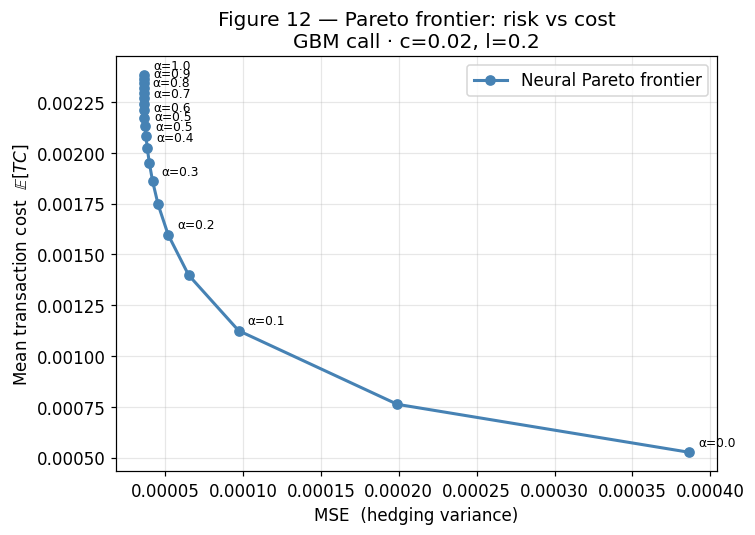

Saved → fig12_pareto_frontier.pdf


In [13]:
# ── Figure 12 — Pareto frontier plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mses_eval, tcs_eval, 'o-', color='steelblue',
        linewidth=2, markersize=6, label='Neural Pareto frontier')

# Annotate key alpha values
for pt in pareto_pts:
    a = pt['alpha']
    if abs(a - round(a, 1)) < 0.03:
        ax.annotate(f"α={a:.1f}",
                    (pt['mse'], pt['tc_mean']),
                    fontsize=8, xytext=(6, 4),
                    textcoords='offset points')

ax.set(xlabel="MSE  (hedging variance)",
       ylabel="Mean transaction cost  $\mathbb{E}[TC]$",
       title=f"Figure 12 — Pareto frontier: risk vs cost\n"
             f"GBM call · c={TC_COST}, l={LIQ_PARETO}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig12_pareto_frontier.pdf'), bbox_inches='tight')
plt.show()
print("Saved → fig12_pareto_frontier.pdf")


## §9 · Save everything

In [14]:
def to_serializable(obj):
    if isinstance(obj, np.ndarray):         return obj.tolist()
    if isinstance(obj, (np.floating,)):     return float(obj)
    if isinstance(obj, (np.integer,)):      return int(obj)
    if isinstance(obj, torch.Tensor):       return obj.detach().cpu().tolist()
    return obj

# Model weights
torch.save(lstm_asym.state_dict(),    os.path.join(OUT, 'lstm_asymmetric.pt'))
torch.save(lstm_m2m4.state_dict(),    os.path.join(OUT, 'lstm_m2m4.pt'))
torch.save(pareto_model.state_dict(), os.path.join(OUT, 'lstm_pareto.pt'))

# P&L arrays
np.save(os.path.join(OUT, 'pnl_lstm_asymmetric.npy'), pnl_asym)
np.save(os.path.join(OUT, 'pnl_lstm_m2m4.npy'),       pnl_m2m4)

# Pareto results
import json
with open(os.path.join(OUT, 'pareto_frontier.json'), 'w') as f:
    json.dump({
        'config': {
            'tc_cost': TC_COST, 'liq': LIQ_PARETO,
            'n_iter': PARETO_ITER, 'batch': PARETO_BATCH,
        },
        'frontier': pareto_pts,
    }, f, indent=2, default=to_serializable)

# Loss comparison summary
loss_summary = {
    'MSE':        {'mse': float(np.mean(pnl_mse_lstm**2)),
                   'var95': float(np.percentile(pnl_mse_lstm, 5)),
                   'cvar95': float(pnl_mse_lstm[pnl_mse_lstm < np.percentile(pnl_mse_lstm,5)].mean())},
    'Asymmetric': {'mse': float(mse_asym),   'premium': float(prem_asym),
                   'var95': float(np.percentile(pnl_asym, 5)),
                   'cvar95': float(pnl_asym[pnl_asym < np.percentile(pnl_asym,5)].mean())},
    'Moment2/4':  {'mse': float(mse_m2m4),   'premium': float(prem_m2m4),
                   'var95': float(np.percentile(pnl_m2m4, 5)),
                   'cvar95': float(pnl_m2m4[pnl_m2m4 < np.percentile(pnl_m2m4,5)].mean())},
}
with open(os.path.join(OUT, 'loss_comparison.json'), 'w') as f:
    json.dump(loss_summary, f, indent=2)

print(f"\n[{time.strftime('%H:%M:%S')}] All done. Saved to {OUT}/")
print()
for fname in sorted(os.listdir(OUT)):
    size = os.path.getsize(os.path.join(OUT, fname))
    print(f"  {fname:<48} {size/1024:>7.1f} KB")



[01:16:50] All done. Saved to c:\Users\monci\OneDrive\Desktop\M2_COURSES\ML_FInance\Project\results_table1/

  fig12_pareto_frontier.pdf                           22.9 KB
  fig9_11_pnl_distributions.pdf                       52.2 KB
  loss_comparison.json                                 0.5 KB
  lstm_asymmetric.pt                                  49.4 KB
  lstm_m2m4.pt                                        49.3 KB
  lstm_pareto.pt                                      77.4 KB
  pareto_frontier.json                                 2.6 KB
  pnl_lstm_asymmetric.npy                            390.8 KB
  pnl_lstm_m2m4.npy                                  390.8 KB
  table1_augmented_lstm_10_10_10.pt                   49.7 KB
  table1_ff_basic_10_10_10.pt                        102.2 KB
  table1_ff_basic_10_15_30.pt                        308.5 KB
  table1_ff_merged_10_10_10.pt                         4.5 KB
  table1_ff_merged_10_15_30.pt                        11.4 KB
  table1_histories.jso

---
## Morning checklist — what to look for in the results

### Section 6.2 — Loss functions (Figures 9–11)

| What to check | Expected |
|---|---|
| Left tail: Asymmetric and Moment2/4 vs MSE | Both should have thinner left tail |
| Right tail: Asymmetric and Moment2/4 vs MSE | Both should have fatter right tail |
| MSE of Asymmetric / Moment2/4 vs MSE model | Slightly higher — they traded MSE for tail protection |
| CVaR 95% of Asymmetric / Moment2/4 vs MSE | Less negative — tail improved |

### Section 7 — Pareto frontier (Figure 12)

| What to check | Expected |
|---|---|
| α=1.0 point | Near the pure-MSE variance (high cost, low variance) |
| α=0.0 point | Near-zero transaction cost (but high variance — does nothing) |
| Curve shape | Downward sloping: lower cost = higher variance |
| Frontier is smooth | If jagged, increase `PARETO_ITER` |
